# Session 3B — Interpretation

Interpret inferred molecular landscapes, residual structure, exploratory clusters, and important limitations.

Work through the parts in order. Each part ends by writing its existing JSON checkpoint,
so the consolidation changes file organization without removing pause/resume milestones.


In [1]:
from pathlib import Path
import sys

# Locates the cloned tutorial in Google Colab after Session 0 setup.
candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
colab_root = Path("/content/ECCB-2026-Tutorial/hands-on_tutorial")
if colab_root.is_dir():
    candidates.insert(0, colab_root.resolve())

for candidate in candidates:
    if (candidate / "src" / "dgat_tutorial").is_dir():
        tutorial_root = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find hands-on_tutorial/. In Colab, run notebooks/session_00/00_colab_setup.ipynb first."
    )

sys.path.insert(0, str(tutorial_root / "src"))

from dgat_tutorial.checkpoints import tutorial_paths, write_checkpoint

paths = tutorial_paths(tutorial_root)
print(f"Tutorial root: {paths.root}")


Tutorial root: /Users/zmengaf/Documents/ECCB tuto/hands-on_tutorial


## Session 3 · Part 3 — Interpret inferred molecular landscapes

**Goal:** move from scores to biological and technical interpretation. We select a well-predicted protein
by Spearman, identify the RNA feature most associated with its measured abundance, compare four spatial
maps on shared color scales, and derive an exploratory embedding from the complete inferred protein panel.
Clustering uses a higher-dimensional PC space; PC1/PC2 are for visualization only.


### 1. Select a protein and a transcript using explicit evidence


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from dgat_tutorial.checkpoints import preferred_prediction_path
from dgat_tutorial.data import load_tutorial_data
from dgat_tutorial.dgat import load_prediction_table
from dgat_tutorial.evaluation import protein_correlations
from dgat_tutorial.plotting import plot_spatial_feature
from dgat_tutorial.processing import normalize_rna_dgat, prepare_evaluation_proteins

dataset = load_tutorial_data(paths.raw_data)
predicted = load_prediction_table(str(preferred_prediction_path(paths)))
common_spots = dataset.spots.index.intersection(dataset.proteins.index).intersection(predicted.index)
if common_spots.empty:
    raise ValueError("Observed and predicted data have no shared spot IDs.")
spots = dataset.spots.loc[common_spots]
observed = prepare_evaluation_proteins(dataset.proteins.loc[common_spots])
predicted = predicted.loc[common_spots]
transcripts = normalize_rna_dgat(dataset.transcripts.loc[common_spots])

correlations = protein_correlations(observed, predicted)
protein = correlations.sort_values("spearman", ascending=False).iloc[0]["protein"]
gene_correlations = transcripts.corrwith(observed[protein]).dropna().sort_values(key=abs, ascending=False)
gene = gene_correlations.index[0]
print(f"Selected protein {protein} (best Spearman on CLR scale); associated transcript {gene} (|r| maximum).")


/Users/zmengaf/miniconda3/envs/eccb-dgat-tutorial/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/zmengaf/miniconda3/envs/eccb-dgat-tutorial/lib/python3.10/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


Alignment report before evaluation: common_spots=4191, common_proteins=31, spots_only_observed=0, spots_only_predicted=0, proteins_only_observed=['mouse_IgG1k', 'mouse_IgG2a', 'mouse_IgG2bk', 'rat_IgG2a'], proteins_only_predicted=[]


/Users/zmengaf/miniconda3/envs/eccb-dgat-tutorial/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/zmengaf/miniconda3/envs/eccb-dgat-tutorial/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Selected protein KRT5 (best Spearman on CLR scale); associated transcript CCL20 (|r| maximum).


#### Figure 14 — Demo2-inspired RNA, observed-protein, and predicted-protein marker panel

Upstream `Demo2_Predict.ipynb` visualizes PAX5, MS4A1, and PDCD1 RNA alongside DGAT
predictions. Because this Tonsil dataset also includes measured ADT, we add the observed protein
as a third view. Each row follows one marker from RNA to measured protein to inferred protein.


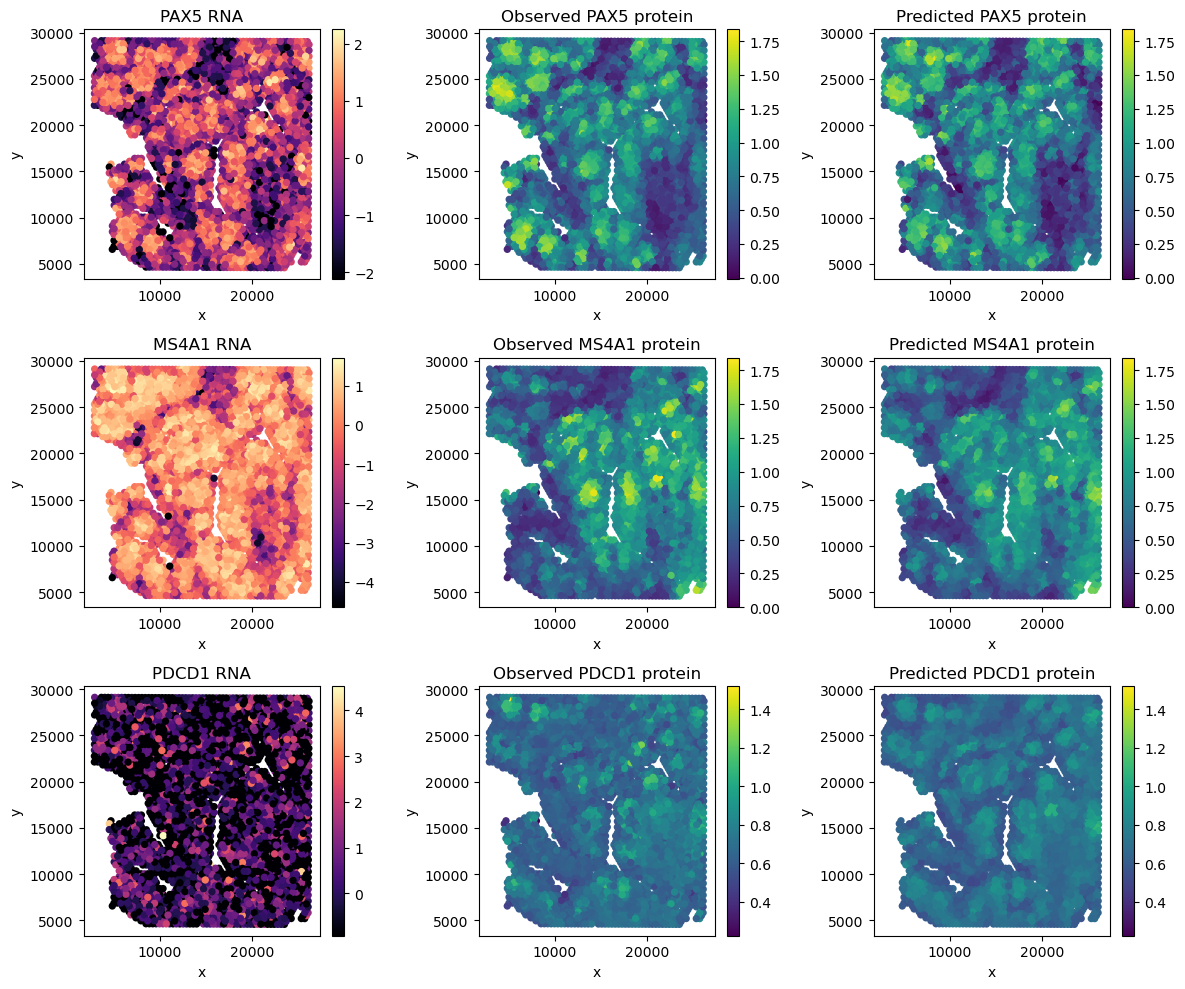

In [3]:
marker_panel = ["PAX5", "MS4A1", "PDCD1"]
missing_rna = [marker for marker in marker_panel if marker not in transcripts.columns]
missing_observed = [marker for marker in marker_panel if marker not in observed.columns]
missing_predicted = [marker for marker in marker_panel if marker not in predicted.columns]
if missing_rna or missing_observed or missing_predicted:
    raise KeyError(
        "Marker panel is incomplete: "
        f"RNA missing={missing_rna}, observed protein missing={missing_observed}, "
        f"predicted protein missing={missing_predicted}"
    )

fig, axes = plt.subplots(len(marker_panel), 3, figsize=(12, 10), squeeze=False)
for row, marker in enumerate(marker_panel):
    # RNA has a different measurement scale. Observed and predicted protein share a row-wise scale.
    protein_vmin = float(min(observed[marker].min(), predicted[marker].min()))
    protein_vmax = float(max(observed[marker].max(), predicted[marker].max()))
    plot_spatial_feature(
        spots, transcripts[marker], f"{marker} RNA", cmap="magma", ax=axes[row, 0]
    )
    plot_spatial_feature(
        spots, observed[marker], f"Observed {marker} protein", ax=axes[row, 1],
        vmin=protein_vmin, vmax=protein_vmax,
    )
    plot_spatial_feature(
        spots, predicted[marker], f"Predicted {marker} protein", ax=axes[row, 2],
        vmin=protein_vmin, vmax=protein_vmax,
    )
marker_panel_path = paths.figures / "session03_demo2_marker_panel.png"
fig.tight_layout(); fig.savefig(marker_panel_path, dpi=180, bbox_inches="tight"); plt.show()


**How to read it:** compare spatial location rather than raw color between the RNA and protein
columns because their scales differ. Within each row, observed and predicted protein use the same
color limits, so range compression, missing regions, and over-smoothed predictions are visible.
Similar RNA and protein maps are possible, but disagreement can reflect translation, trafficking,
degradation, antibody behavior, or model error.


#### Figure 15 — Transcript, measured protein, inferred protein, and residual


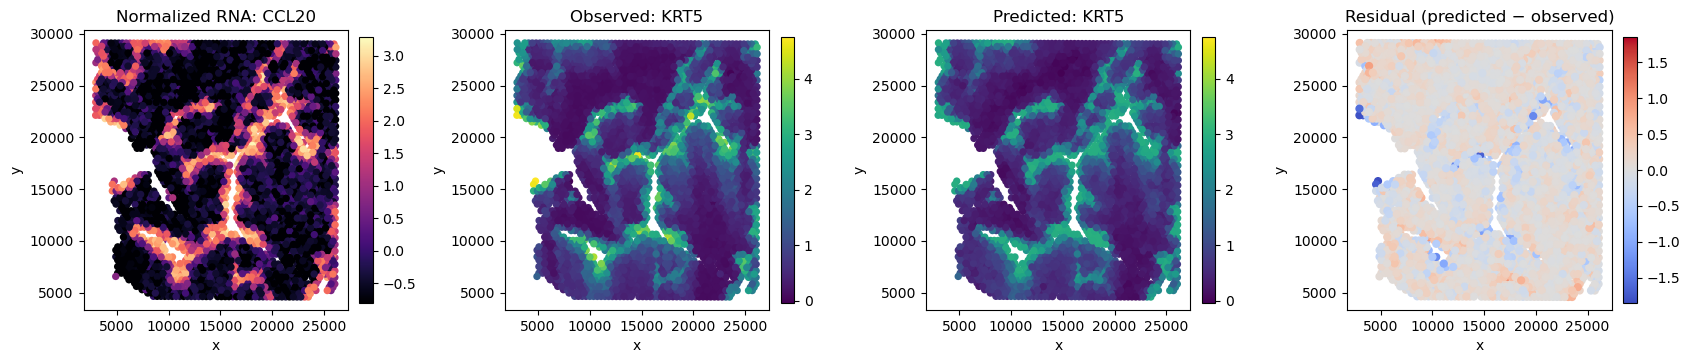

In [4]:
residual = predicted[protein] - observed[protein]
limit = float(np.abs(residual).max())
shared_vmin = float(min(observed[protein].min(), predicted[protein].min()))
shared_vmax = float(max(observed[protein].max(), predicted[protein].max()))
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
plot_spatial_feature(spots, transcripts[gene], f"Normalized RNA: {gene}", cmap="magma", ax=axes[0])
plot_spatial_feature(
    spots, observed[protein], f"Observed: {protein}", ax=axes[1], vmin=shared_vmin, vmax=shared_vmax
)
plot_spatial_feature(
    spots, predicted[protein], f"Predicted: {protein}", ax=axes[2], vmin=shared_vmin, vmax=shared_vmax
)
residual_scatter = axes[3].scatter(spots["x"], spots["y"], c=residual, cmap="coolwarm", vmin=-limit, vmax=limit, s=24)
axes[3].set(title="Residual (predicted − observed)", xlabel="x", ylabel="y", aspect="equal")
plt.colorbar(residual_scatter, ax=axes[3], fraction=0.046, pad=0.04)
landscape_path = paths.figures / "session03_landscape_comparison.png"
fig.tight_layout(); fig.savefig(landscape_path, dpi=160, bbox_inches="tight"); plt.show()


**How to read it:** spatially localized residuals may reveal tissue boundaries, composition shifts,
antibody effects, or a domain shift. Transcript–protein discordance can be biological because translation,
trafficking, and degradation separate RNA abundance from surface-protein abundance. Observed and predicted
maps share one color scale so intensity differences are visually comparable.


#### Figure 16 — Downstream structure inferred from the full protein panel


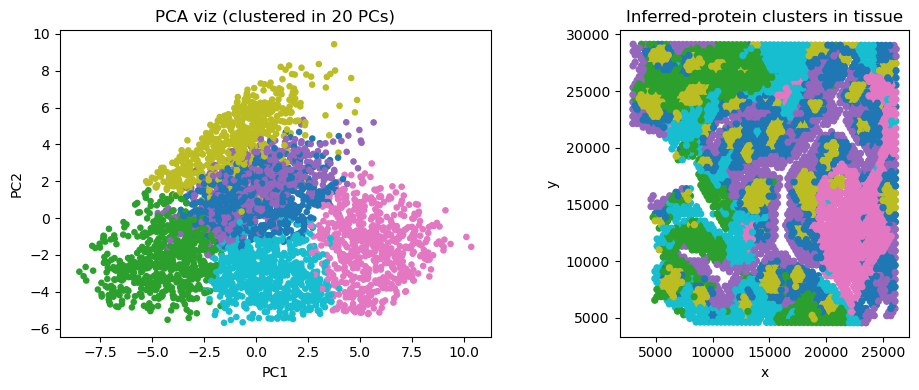

In [5]:
scaled = (predicted - predicted.mean(axis=0)) / (predicted.std(axis=0) + 1e-8)
n_pcs = min(20, scaled.shape[0] - 1, scaled.shape[1])
pcs = PCA(n_components=n_pcs, random_state=7).fit_transform(scaled)
# Arbitrary exploratory k; assess stability before biological claims.
n_clusters = min(6, max(2, len(predicted) // 100))
clusters = KMeans(n_clusters=n_clusters, n_init=20, random_state=7).fit_predict(pcs)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(pcs[:, 0], pcs[:, 1], c=clusters, cmap="tab10", s=14)
axes[0].set(title=f"PCA viz (clustered in {n_pcs} PCs)", xlabel="PC1", ylabel="PC2")
axes[1].scatter(spots["x"], spots["y"], c=clusters, cmap="tab10", s=18)
axes[1].set(title="Inferred-protein clusters in tissue", xlabel="x", ylabel="y", aspect="equal")
embedding_path = paths.figures / "session03_inferred_protein_embedding.png"
fig.tight_layout(); fig.savefig(embedding_path, dpi=160, bbox_inches="tight"); plt.show()


These clusters are hypotheses, not validated cell types. Annotate them only after checking marker panels,
spatial context, robustness to cluster count, and agreement with observed modalities or orthogonal data.


In [6]:
prompts = (
    "# Session 3 interpretation prompts\n\n"
    "- Which proteins are accurate pointwise but spatially over-smoothed?\n"
    "- Where are residuals spatially localized, and what technical or biological process could explain them?\n"
    "- Which multi-protein clusters are stable and supported by known marker combinations?\n"
    "- What donor, batch, antibody, tissue-boundary, or cell-composition effects could mislead evaluation?\n"
    "- What held-out dataset would best test generalization?\n"
)
prompt_path = paths.results / "session03_interpretation_prompts.md"
prompt_path.write_text(prompts, encoding="utf-8")
manifest = write_checkpoint(
    "3.3", [marker_panel_path, landscape_path, embedding_path, prompt_path],
    summary={"transcript": gene, "protein": protein, "exploratory_clusters": n_clusters, "n_pcs": n_pcs},
    start=paths.root,
)
print(prompts); print(f"Checkpoint written: {manifest}")


# Session 3 interpretation prompts

- Which proteins are accurate pointwise but spatially over-smoothed?
- Where are residuals spatially localized, and what technical or biological process could explain them?
- Which multi-protein clusters are stable and supported by known marker combinations?
- What donor, batch, antibody, tissue-boundary, or cell-composition effects could mislead evaluation?
- What held-out dataset would best test generalization?

Checkpoint written: /Users/zmengaf/Documents/ECCB tuto/hands-on_tutorial/checkpoints/session_03/part_3_3.json


### Next steps

A complete analysis now has three evidence layers: per-protein accuracy, spatial fidelity, and biological
interpretation. Before publication, repeat all three on held-out biological samples and include uncertainty
or replicate variability—not only a single fitted map.
